In [1]:
import numpy as np 
import pandas as pd 
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
import kagglehub

/kaggle/input/competitions/pokemon-tcg-ai-battle-challenge-strategy/Card_ID List_JP.pdf
/kaggle/input/competitions/pokemon-tcg-ai-battle-challenge-strategy/Card_ID List_EN.pdf
/kaggle/input/competitions/pokemon-tcg-ai-battle-challenge-strategy/EN_Card_Data.csv
/kaggle/input/competitions/pokemon-tcg-ai-battle-challenge-strategy/JP_Card_Data.csv


In [3]:
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if filename == 'EN_Card_Data.csv':

            full_path = os.path.join(dirname, filename)
            print(f"Files found in: {full_path}")

Files found in: /kaggle/input/competitions/pokemon-tcg-ai-battle-challenge-strategy/EN_Card_Data.csv


In [4]:
file_path = '/kaggle/input/competitions/pokemon-tcg-ai-battle-challenge-strategy/EN_Card_Data.csv' 
df = pd.read_csv(file_path)

print("Data loaded successfully!")
df.head()

Data loaded successfully!


,Card ID,Card Name,Expansion,Collection No.,Stage (Pokémon)/Type (Energy and Trainer),Rule,Category,Previous stage,HP,Type,Weakness,Resistance (Type),Retreat,Move Name,Cost,Damage,Effect Explanation
0,1,Basic {G} Energy,SVE,1,Basic Energy,NaN,NaN,NaN,NaN,{G},NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,Basic {R} Energy,SVE,2,Basic Energy,NaN,NaN,NaN,NaN,{R},NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,Basic {W} Energy,SVE,3,Basic Energy,NaN,NaN,NaN,NaN,{W},NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,Basic {L} Energy,SVE,4,Basic Energy,NaN,NaN,NaN,NaN,{L},NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,Basic {P} Energy,SVE,5,Basic Energy,NaN,NaN,NaN,NaN,{P},NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
print("Categories in the dataset:")
print(df['Category'].value_counts())

pokemon_only = df[df['Category'] == 'Pokémon']
print(f"\nTotal unique Pokémon entries: {len(pokemon_only)}")

Categories in the dataset:
Category
Trainer's Pokémon（Team Rocket）    85
Tera(Stellar)                     60
Ancient                           26
Trainer's Pokémon（N）              26
Trainer's Pokémon（Hop）            21
Future                            17
Trainer's Pokémon（Ethan）          15
Trainer's Pokémon（Larry）          13
Trainer's Pokémon（Steven）         12
Trainer's Pokémon（Marnie）         11
Trainer's Pokémon（Erika）          11
Trainer's Pokémon（Cynthia）        11
Trainer's Pokémon（Misty）          10
Fossil                            10
Trainer's Pokémon（Arven）          10
Tera(Lightning)                    9
Tera(Fighting)                     9
Trainer's Pokémon（Iono）            9
Trainer's Pokémon（Lillie）          7
Tera(Fire)                         6
Tera(Darkness)                     3
Tera(Water)                        3
Tera(Grass)                        3
Tera(Dragon)                       3
Technical Machine                  2
Name: count, dtype: int64

Total unique

In [6]:
print(df.columns)

pokemon_by_hp = df[df['HP'].notna()]
print(f"\nNumber of cards that have HP value: {len(pokemon_by_hp)}")

Index(['Card ID', 'Card Name', 'Expansion', 'Collection No.',
       'Stage (Pokémon)/Type (Energy and Trainer)', 'Rule', 'Category',
       'Previous stage', 'HP', 'Type', 'Weakness', 'Resistance (Type)',
       'Retreat', 'Move Name', 'Cost', 'Damage', 'Effect Explanation'],
      dtype='object')

Number of cards that have HP value: 1815


In [7]:
print(df['Stage (Pokémon)/Type (Energy and Trainer)'].value_counts())

Stage (Pokémon)/Type (Energy and Trainer)
Basic Pokémon      958
Stage 1 Pokémon    618
Stage 2 Pokémon    229
Item                82
Supporter           61
Pokémon Tool        28
Stadium             26
Special Energy      12
Basic Energy         8
Name: count, dtype: int64


In [8]:
def get_card_priority(stage):
    if 'Stage 2' in str(stage):
        return 3
    elif 'Stage 1' in str(stage):
        return 2
    elif 'Basic Pokémon' in str(stage):
        return 1
    else:
        return 0
df['Priority'] = df['Stage (Pokémon)/Type (Energy and Trainer)'].apply(get_card_priority)
print(df[df['Priority'] == 3][['Card Name', 'HP', 'Priority']].head(10))

         Card Name     HP  Priority
56     Greninja ex  310.0         3
57     Greninja ex  310.0         3
58     Greninja ex  310.0         3
73      Feraligatr  180.0         3
74      Feraligatr  180.0         3
112        Shiftry  150.0         3
113        Shiftry  150.0         3
127  Incineroar ex  320.0         3
128  Incineroar ex  320.0         3
152      Rillaboom  180.0         3


In [9]:
df_clean = df.drop_duplicates(subset=['Card Name'])
stage2_unique = df_clean[df_clean['Priority'] == 3]

print(f"Number of unique Stage 2s available: {len(stage2_unique)}")
print(stage2_unique[['Card Name', 'HP']].sort_values(by='HP', ascending=False).head(10))

Number of unique Stage 2s available: 104
                Card Name     HP
1585       Mega Emboar ex  380.0
1138     Mega Venusaur ex  380.0
1594   Mega Feraligatr ex  370.0
1545    Mega Dragonite ex  370.0
1571     Mega Meganium ex  360.0
1581  Mega Charizard Y ex  360.0
1290    Mega Gardevoir ex  360.0
1362  Mega Charizard X ex  360.0
1488   Mega Eelektross ex  350.0
1334       Mega Gengar ex  350.0


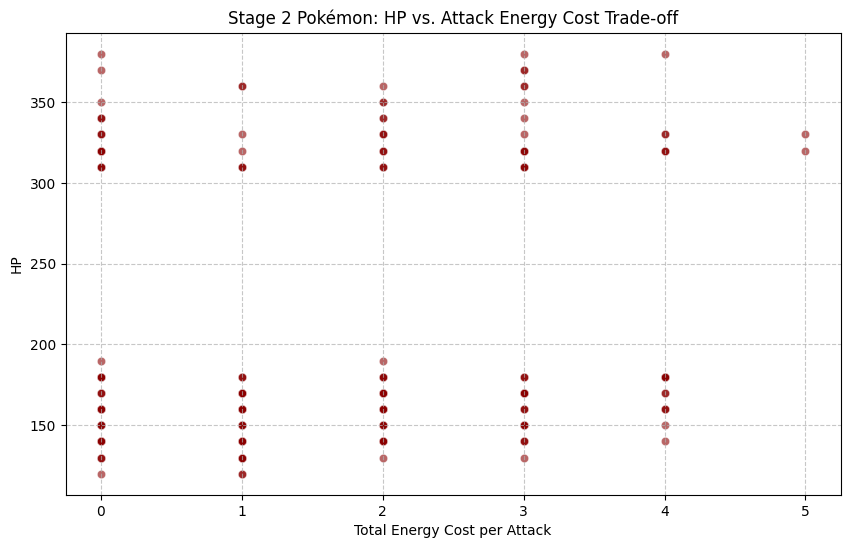

In [10]:
def parse_energy_cost(cost_str):
    if pd.isna(cost_str) or cost_str == 'No cost':
        return 0
    cost_str = str(cost_str)
    return cost_str.count('{') + cost_str.count('●')

stage2_names = stage2_unique['Card Name'].tolist()
stage2_attacks = df[df['Card Name'].isin(stage2_names)].copy()
stage2_attacks['Energy_Cost'] = stage2_attacks['Cost'].apply(parse_energy_cost)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=stage2_attacks, x='Energy_Cost', y='HP', alpha=0.6, color='darkred')
plt.title('Stage 2 Pokémon: HP vs. Attack Energy Cost Trade-off')
plt.xlabel('Total Energy Cost per Attack')
plt.ylabel('HP')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [11]:
efficient_monsters = stage2_attacks[(stage2_attacks['HP'] > 200) & (stage2_attacks['Energy_Cost'] <= 2)]

print("Top Efficient Stage 2 Pokémon for your Deck:")
print(efficient_monsters[['Card Name', 'HP', 'Energy_Cost']].drop_duplicates().sort_values(by='HP', ascending=False).head(10))

Top Efficient Stage 2 Pokémon for your Deck:
                  Card Name     HP  Energy_Cost
1138       Mega Venusaur ex  380.0            0
1545      Mega Dragonite ex  370.0            0
1290      Mega Gardevoir ex  360.0            1
1362    Mega Charizard X ex  360.0            2
1335         Mega Gengar ex  350.0            2
1334         Mega Gengar ex  350.0            0
1488     Mega Eelektross ex  350.0            2
1123  Steven's Metagross ex  340.0            0
428              Slaking ex  340.0            2
522            Mamoswine ex  340.0            2


In [12]:
god_tier_cards = efficient_monsters.drop_duplicates(subset=['Card Name'])

def build_my_deck(all_cards, top_n=5):
    all_cards['Score'] = all_cards['HP'] / (all_cards['Energy_Cost'] + 1)
    
    deck = all_cards.sort_values(by='Score', ascending=False).head(top_n)
    return deck[['Card Name', 'HP', 'Energy_Cost', 'Score']]

print("AI-Recommended Core Deck:")
print(build_my_deck(god_tier_cards))

AI-Recommended Core Deck:
                  Card Name     HP  Energy_Cost  Score
1138       Mega Venusaur ex  380.0            0  380.0
1545      Mega Dragonite ex  370.0            0  370.0
1334         Mega Gengar ex  350.0            0  350.0
1123  Steven's Metagross ex  340.0            0  340.0
427              Slaking ex  340.0            0  340.0


/tmp/ipykernel_16/420329152.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_cards['Score'] = all_cards['HP'] / (all_cards['Energy_Cost'] + 1)
